# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Septyan Yaumul Fatkhan
- **Email:** alfathseptyan02@gmail.com
- **ID Dicoding:** alfseptyan

**Tentang dataset:** data transaksi nyata marketplace Olist (Brasil) periode 2016–2018 yang terdiri dari beberapa tabel relasional: pelanggan, pesanan, item pesanan, produk, ulasan, penjual, pembayaran, dan geolokasi.

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa saja yang menjadi 10 penyumbang revenue terbesar pada pesanan yang berhasil terkirim selama Januari 2017 – Agustus 2018, dan berapa persen pertumbuhan revenue masing-masing kategori pada periode Januari–Agustus 2018 dibandingkan Januari–Agustus 2017? *(Hasilnya dipakai tim merchandising untuk menentukan kategori yang diprioritaskan untuk promosi dan penambahan seller.)*
- **Pertanyaan 2:** Seberapa besar keterlambatan pengiriman (tanggal diterima pelanggan melewati estimasi) menurunkan rata-rata review score pelanggan, dan di 5 state mana persentase pesanan terlambatnya paling tinggi selama Januari 2017 – Agustus 2018? *(Hasilnya dipakai tim logistik untuk menentukan wilayah prioritas perbaikan pengiriman.)*

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Data Wrangling

### Gathering Data

#### Load seluruh tabel yang dibutuhkan

In [2]:
data_path = "data/"

customers_df = pd.read_csv(data_path + "olist_customers_dataset.csv")
orders_df = pd.read_csv(data_path + "olist_orders_dataset.csv")
items_df = pd.read_csv(data_path + "olist_order_items_dataset.csv")
products_df = pd.read_csv(data_path + "olist_products_dataset.csv")
category_df = pd.read_csv(data_path + "product_category_name_translation.csv")
reviews_df = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")

for name, df in [("customers", customers_df), ("orders", orders_df), ("order_items", items_df),
                 ("products", products_df), ("category_translation", category_df), ("reviews", reviews_df)]:
    print(f"{name:22s} -> {df.shape[0]:>7,} baris x {df.shape[1]} kolom")

customers              ->  99,441 baris x 5 kolom
orders                 ->  99,441 baris x 8 kolom
order_items            -> 112,650 baris x 7 kolom
products               ->  32,951 baris x 9 kolom
category_translation   ->      71 baris x 2 kolom
reviews                ->  99,224 baris x 7 kolom


In [3]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Enam tabel berhasil dimuat: `customers`, `orders`, `order_items`, `products`, `category_translation`, dan `reviews` (tabel `sellers`, `payments`, dan `geolocation` tidak dipakai karena tidak dibutuhkan untuk menjawab kedua pertanyaan).
- `order_id` menjadi kunci penghubung `orders`-`order_items`-`reviews`, `customer_id` menghubungkan `orders`-`customers`, dan `product_id` menghubungkan `order_items`-`products`.
- Satu pesanan bisa berisi beberapa item, sehingga analisis yang berbasis pesanan (review, keterlambatan) harus dihitung pada level `order_id` agar tidak terhitung ganda.

### Assessing Data

#### Identifying missing value & tipe data pada tabel orders

In [5]:
orders_df.info()
print("\nMissing value:")
print(orders_df.isna().sum()[lambda s: s > 0])

# apakah missing value berkaitan dengan status pesanan?
print("\nMissing order_delivered_customer_date per status:")
print(orders_df[orders_df["order_delivered_customer_date"].isna()]["order_status"].value_counts())
print("\nStatus 'delivered' tetapi tanggal diterima kosong:",
      ((orders_df["order_status"] == "delivered") & orders_df["order_delivered_customer_date"].isna()).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing value:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Missing order_delivered_customer_date per status:
order_status
shipped        1107
canceled        619
unavailable    

#### Identifying cakupan periode data

In [6]:
order_month = pd.to_datetime(orders_df["order_purchase_timestamp"]).dt.to_period("M")
print(order_month.value_counts().sort_index().to_string())

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M


#### Identifying missing value pada tabel products

In [7]:
print(products_df.isna().sum()[lambda s: s > 0])

# kategori yang belum punya terjemahan Inggris
missing_translation = set(products_df["product_category_name"].dropna()) - set(category_df["product_category_name"])
print("\nKategori tanpa terjemahan:", missing_translation)

product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Kategori tanpa terjemahan: {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}


#### Identifying duplikasi pada tabel reviews

In [8]:
print("Duplikat baris penuh :", reviews_df.duplicated().sum())
print("order_id muncul >1 kali:", reviews_df["order_id"].duplicated().sum())
print("review_id duplikat     :", reviews_df["review_id"].duplicated().sum())
reviews_df[reviews_df["order_id"].duplicated(keep=False)].sort_values("order_id").head(6)

Duplikat baris penuh : 0


order_id muncul >1 kali: 551
review_id duplikat     : 814


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47


#### Identifying outlier pada harga & ongkir

In [9]:
q1, q3 = items_df["price"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print(f"Batas atas IQR harga: {upper:,.2f}")
print(f"Jumlah item di atas batas: {(items_df['price'] > upper).sum():,} ({(items_df['price'] > upper).mean():.1%})")
items_df[["price", "freight_value"]].describe()

Batas atas IQR harga: 277.40
Jumlah item di atas batas: 8,427 (7.5%)


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


**Steps to Take:**
1. **Missing value & tipe data `orders`:** kolom tanggal masih bertipe `object` → ubah ke `datetime`. Tanggal kosong hampir seluruhnya berasal dari pesanan yang belum/tidak terkirim (canceled, unavailable, shipped, dst.) sehingga bukan error input. Analisis ini difokuskan pada pesanan berstatus `delivered` yang tanggal diterimanya terisi; sisanya dikeluarkan.
2. **Cakupan periode:** 2016 hanya berisi ±330 pesanan dan Sep–Okt 2018 hanya 20 pesanan (data belum lengkap) → batasi analisis pada **Jan 2017 – Agu 2018** agar perbandingan bulan/tahun adil.
3. **Missing value `products`:** 610 produk tanpa kategori → isi `unknown`; 2 kategori tanpa terjemahan (`pc_gamer`, `portateis_cozinha_e_preparadores_de_alimentos`) → terjemahkan manual lalu gabungkan dengan tabel terjemahan.
4. **Duplikasi `reviews`:** ada order dengan lebih dari satu ulasan → ambil ulasan terbaru per `order_id` agar review score tidak terhitung ganda saat di-merge.
5. **Outlier harga:** sebagian item bernilai sangat tinggi, tetapi merupakan produk mahal yang valid (bukan salah input) → **dipertahankan**, dan analisis memakai total & persentase agar tidak bias oleh median/mean saja.

**Insight:**
- Data mentah memuat **99.441 pesanan** tetapi hanya 96.478 berstatus `delivered`; 2.965 tanggal diterima kosong hampir semuanya milik pesanan yang belum/tidak sampai (shipped, canceled, unavailable, dst.).
- Hanya 8 pesanan `delivered` yang tanggal diterimanya kosong, jumlah yang sangat kecil sehingga aman dibuang.
- Volume data 2016 dan Sep-Okt 2018 sangat kecil dibanding bulan lain (4-324 pesanan vs ribuan), jika ikut dihitung akan membuat perbandingan antar periode menyesatkan.
- 551 pesanan memiliki ulasan ganda (814 `review_id` terkait pesanan yang sama) dan 610 produk tidak punya kategori.
- Sekitar 7,5% item tergolong outlier harga menurut IQR, tetapi nilainya konsisten dengan produk premium (maks. R$ 6.735) sehingga dipertahankan.

### Cleaning Data

#### Fixing tipe data, status & periode pada orders

In [10]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

orders_clean = orders_df[
    (orders_df["order_status"] == "delivered")
    & orders_df["order_delivered_customer_date"].notna()
    & (orders_df["order_purchase_timestamp"] >= "2017-01-01")
    & (orders_df["order_purchase_timestamp"] < "2018-09-01")
].copy()

print(f"Sebelum: {len(orders_df):,} pesanan -> sesudah: {len(orders_clean):,} pesanan")
print(orders_clean["order_purchase_timestamp"].min(), "s/d", orders_clean["order_purchase_timestamp"].max())

Sebelum: 99,441 pesanan -> sesudah: 96,203 pesanan
2017-01-05 11:56:06 s/d 2018-08-29 15:00:37


#### Fixing missing value & terjemahan kategori pada products

In [11]:
manual_translation = {
    "pc_gamer": "pc_gamer",
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_preparers",
}
category_map = dict(zip(category_df["product_category_name"], category_df["product_category_name_english"]))
category_map.update(manual_translation)

products_clean = products_df[["product_id", "product_category_name"]].copy()
products_clean["product_category_name"] = products_clean["product_category_name"].fillna("unknown")
products_clean["product_category_english"] = products_clean["product_category_name"].map(category_map).fillna("unknown")

print("Kategori belum terterjemahkan:", (products_clean["product_category_english"].isna()).sum())
print("Produk 'unknown':", (products_clean["product_category_english"] == "unknown").sum())

Kategori belum terterjemahkan: 0
Produk 'unknown': 610


#### Fixing duplikasi pada reviews

In [12]:
reviews_clean = (reviews_df
                 .sort_values("review_answer_timestamp")
                 .drop_duplicates(subset="order_id", keep="last")[["order_id", "review_score"]])
print(f"Sebelum: {len(reviews_df):,} -> sesudah: {len(reviews_clean):,} | order_id duplikat: {reviews_clean['order_id'].duplicated().sum()}")

Sebelum: 99,224 -> sesudah: 98,673 | order_id duplikat: 0


#### Menggabungkan tabel & membuat fitur pengiriman (main_df)

In [13]:
main_df = (orders_clean
           .merge(customers_df[["customer_id", "customer_unique_id", "customer_state"]], on="customer_id", how="left")
           .merge(items_df[["order_id", "product_id", "price", "freight_value"]], on="order_id", how="inner")
           .merge(products_clean[["product_id", "product_category_english"]], on="product_id", how="left")
           .merge(reviews_clean, on="order_id", how="left"))

main_df["product_category_english"] = main_df["product_category_english"].fillna("unknown")

# fitur pengiriman
main_df["delivery_days"] = (main_df["order_delivered_customer_date"] - main_df["order_purchase_timestamp"]).dt.days
main_df["delay_days"] = (main_df["order_delivered_customer_date"].dt.normalize()
                         - main_df["order_estimated_delivery_date"].dt.normalize()).dt.days
main_df["is_late"] = main_df["delay_days"] > 0
main_df["delay_bucket"] = pd.cut(main_df["delay_days"], bins=[-np.inf, 0, 3, 7, np.inf],
                                 labels=["Tepat waktu / lebih cepat", "Telat 1-3 hari", "Telat 4-7 hari", "Telat > 7 hari"]).astype(str)

keep_cols = ["order_id", "customer_unique_id", "customer_state", "order_purchase_timestamp",
             "order_delivered_customer_date", "order_estimated_delivery_date", "product_category_english",
             "price", "freight_value", "review_score", "delivery_days", "delay_days", "is_late", "delay_bucket"]
main_df = main_df[keep_cols]

print("Shape main_df:", main_df.shape)
print("Missing value:\n", main_df.isna().sum()[lambda s: s > 0])
main_df.head()

Shape main_df: (109872, 14)
Missing value:
 review_score    823
dtype: int64


,order_id,customer_unique_id,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_category_english,price,freight_value,review_score,delivery_days,delay_days,is_late,delay_bucket
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,housewares,29.99,8.72,4.0,8,-8,False,Tepat waktu / lebih cepat
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,perfumery,118.70,22.76,4.0,13,-6,False,Tepat waktu / lebih cepat
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,auto,159.90,19.22,5.0,9,-18,False,Tepat waktu / lebih cepat
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,pet_shop,45.00,27.20,5.0,13,-13,False,Tepat waktu / lebih cepat
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,stationery,19.90,8.72,5.0,2,-10,False,Tepat waktu / lebih cepat


In [14]:
# simpan data bersih untuk dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)
print("main_data.csv tersimpan:", main_df.shape)

main_data.csv tersimpan: (109872, 14)


**Insight:**
- Setelah pembersihan tersisa **96.203 pesanan** (109.872 baris item) berstatus `delivered` pada periode **Jan 2017 - Agu 2018**.
- Semua produk kini punya kategori berbahasa Inggris (610 produk ditandai `unknown`), dan ulasan sudah unik per pesanan.
- Hanya 823 baris item (643 pesanan) yang belum memiliki review; baris ini dikeluarkan saat menghitung rata-rata review, bukan diisi nilai buatan.
- Fitur baru `delivery_days`, `delay_days`, `is_late`, dan `delay_bucket` dibuat dari selisih tanggal diterima terhadap estimasi, lalu data disimpan sebagai `dashboard/main_data.csv`.

## Exploratory Data Analysis (EDA)

### Explore ringkasan data & Pertanyaan 1 (revenue per kategori)

In [15]:
print("Pesanan unik     :", f"{main_df['order_id'].nunique():,}")
print("Pelanggan unik   :", f"{main_df['customer_unique_id'].nunique():,}")
print("Total revenue    :", f"R$ {main_df['price'].sum():,.0f}")
print("Rata-rata review :", f"{main_df.drop_duplicates('order_id')['review_score'].mean():.2f}")
main_df[["price", "freight_value", "delivery_days", "delay_days", "review_score"]].describe()

Pesanan unik     : 96,203
Pelanggan unik   : 93,096
Total revenue    : R$ 13,179,778
Rata-rata review : 4.16


,price,freight_value,delivery_days,delay_days,review_score
count,109872.000000,109872.000000,109872.000000,109872.000000,109049.000000
mean,119.955748,19.950152,11.985993,-11.959608,4.082449
std,182.351343,15.704075,9.433554,10.060968,1.346612
min,0.850000,0.000000,0.000000,-147.000000,1.000000
25%,39.900000,13.080000,6.000000,-17.000000,4.000000
50%,74.900000,16.260000,10.000000,-13.000000,5.000000
75%,134.042500,21.150000,15.000000,-7.000000,5.000000
max,6735.000000,409.680000,209.000000,188.000000,5.000000


In [16]:
# Tren bulanan
monthly = (main_df.assign(month=main_df["order_purchase_timestamp"].dt.to_period("M"))
           .groupby("month").agg(orders=("order_id", "nunique"), revenue=("price", "sum")))
monthly

,orders,revenue
month,,
2017-01,750,111798.36
2017-02,1653,234223.40
2017-03,2546,359198.85
2017-04,2303,340669.68
2017-05,3545,489159.25
2017-06,3135,421923.37
2017-07,3872,481604.52
2017-08,4193,554699.70
2017-09,4150,607399.67


In [17]:
# Top 10 kategori berdasarkan revenue
cat_summary = (main_df.groupby("product_category_english")
               .agg(revenue=("price", "sum"), orders=("order_id", "nunique"), avg_price=("price", "mean"))
               .sort_values("revenue", ascending=False))
cat_summary["revenue_share_%"] = cat_summary["revenue"] / cat_summary["revenue"].sum() * 100
top10 = cat_summary.head(10)
print(f"10 kategori teratas menyumbang {top10['revenue_share_%'].sum():.1f}% total revenue")
top10

10 kategori teratas menyumbang 62.5% total revenue


,revenue,orders,avg_price,revenue_share_%
product_category_english,,,,
health_beauty,1229557.50,8610,130.498567,9.329122
watches_gifts,1163187.91,5489,198.733625,8.825550
bed_bath_table,1022955.77,9267,93.463296,7.761555
sports_leisure,952661.40,7512,113.236824,7.228205
computers_accessories,887944.60,6517,116.360189,6.737174
furniture_decor,706237.17,6258,87.243628,5.358491
housewares,614341.62,5734,90.570783,4.661244
cool_stuff,609158.00,3552,164.149286,4.621914
auto,577721.09,3801,139.850179,4.383390


In [18]:
# Pertumbuhan revenue Jan-Agu 2018 vs Jan-Agu 2017 (periode sama agar adil)
jan_aug = main_df[main_df["order_purchase_timestamp"].dt.month <= 8]
rev_year = jan_aug.pivot_table(index="product_category_english",
                               columns=jan_aug["order_purchase_timestamp"].dt.year,
                               values="price", aggfunc="sum")
growth = ((rev_year[2018] / rev_year[2017] - 1) * 100).rename("growth_%")
top10_growth = top10.join(rev_year[[2017, 2018]]).join(growth)
print(f"Pertumbuhan total revenue Jan-Agu: {(rev_year[2018].sum() / rev_year[2017].sum() - 1) * 100:.1f}%")
top10_growth[["revenue", 2017, 2018, "growth_%"]].round(1)

Pertumbuhan total revenue Jan-Agu: 141.1%


,revenue,2017,2018,growth_%
product_category_english,,,,
health_beauty,1229557.5,243521.7,755724.5,210.3
watches_gifts,1163187.9,201137.9,687577.2,241.8
bed_bath_table,1022955.8,254444.8,532358.8,109.2
sports_leisure,952661.4,216545.3,517166.3,138.8
computers_accessories,887944.6,214631.3,496158.3,131.2
furniture_decor,706237.2,170858.6,381649.6,123.4
housewares,614341.6,127534.5,391823.5,207.2
cool_stuff,609158.0,206306.4,227743.7,10.4
auto,577721.1,125247.5,343288.3,174.1


**Insight:**
- Total revenue produk periode analisis sebesar **R$ 13,18 juta** dari 96.203 pesanan dan 93.096 pelanggan unik; rata-rata review 4,16.
- Revenue bulanan naik tajam sepanjang 2017 dan puncaknya jatuh pada **November 2017** (R$ 987 ribu, efek Black Friday), lalu stabil di kisaran R$ 830-980 ribu per bulan pada 2018.
- **10 kategori teratas menyumbang 62,5% revenue.** Peringkat 1-3 adalah `health_beauty` (R$ 1,23 juta), `watches_gifts` (R$ 1,16 juta), dan `bed_bath_table` (R$ 1,02 juta).
- Dua kategori teratas punya karakter berbeda: `health_beauty` menang di volume (8.610 pesanan), sedangkan `watches_gifts` menang di nilai per item (rata-rata R$ 199 vs R$ 130).
- Pada periode yang sama (Jan-Agu), revenue 2018 tumbuh 141% dibanding 2017. Seluruh 10 kategori teratas tumbuh positif; tercepat `watches_gifts` (+242%), `health_beauty` (+210%), dan `housewares` (+207%), sedangkan yang paling lambat `cool_stuff` (+10%) dan `garden_tools` (+54%).
- Catatan: sebagian pertumbuhan terjadi karena platform masih berkembang pada awal 2017 (Jan 2017 baru 750 pesanan), sehingga angka YoY lebih tepat dibaca sebagai perbandingan antar kategori, bukan pertumbuhan organik murni.

### Explore Pertanyaan 2 (keterlambatan pengiriman, review score, dan wilayah)

In [19]:
# level pesanan (1 baris per order) agar review & keterlambatan tidak terhitung ganda per item
order_level = main_df.drop_duplicates("order_id").copy()

print(f"Pesanan terlambat : {order_level['is_late'].mean():.1%}")
print(f"Rata-rata lama kirim: {order_level['delivery_days'].mean():.1f} hari | rata-rata selisih dari estimasi: {order_level['delay_days'].mean():.1f} hari")
print("Pesanan tanpa review:", order_level["review_score"].isna().sum())

bucket_order = ["Tepat waktu / lebih cepat", "Telat 1-3 hari", "Telat 4-7 hari", "Telat > 7 hari"]
review_by_delay = (order_level.dropna(subset=["review_score"])
                   .groupby("delay_bucket")
                   .agg(orders=("order_id", "count"), avg_review=("review_score", "mean"),
                        pct_score_1_2=("review_score", lambda s: (s <= 2).mean() * 100))
                   .reindex(bucket_order))
review_by_delay["pct_orders_%"] = review_by_delay["orders"] / review_by_delay["orders"].sum() * 100
review_by_delay.round(2)

Pesanan terlambat : 6.8%
Rata-rata lama kirim: 12.1 hari | rata-rata selisih dari estimasi: -11.8 hari
Pesanan tanpa review: 643


,orders,avg_review,pct_score_1_2,pct_orders_%
delay_bucket,,,,
Tepat waktu / lebih cepat,89182,4.29,9.25,93.33
Telat 1-3 hari,1851,3.29,32.14,1.94
Telat 4-7 hari,1748,2.10,67.68,1.83
Telat > 7 hari,2779,1.70,79.27,2.91


In [20]:
late_vs_ontime = order_level.dropna(subset=["review_score"]).groupby("is_late")["review_score"].mean()
print(f"Rata-rata review tepat waktu: {late_vs_ontime[False]:.2f} | terlambat: {late_vs_ontime[True]:.2f} | selisih: {late_vs_ontime[False] - late_vs_ontime[True]:.2f} poin")
print("Korelasi delay_days vs review_score:", round(order_level[["delay_days", "review_score"]].corr().iloc[0, 1], 3))

Rata-rata review tepat waktu: 4.29 | terlambat: 2.27 | selisih: 2.02 poin
Korelasi delay_days vs review_score: -0.27


In [21]:
# persentase terlambat per state (minimal 300 pesanan agar tidak bias oleh sampel kecil)
state_summary = (order_level.groupby("customer_state")
                 .agg(orders=("order_id", "count"), late_pct=("is_late", lambda s: s.mean() * 100),
                      avg_delivery_days=("delivery_days", "mean"), avg_review=("review_score", "mean")))
state_summary = state_summary[state_summary["orders"] >= 300].sort_values("late_pct", ascending=False)
top5_late = state_summary.head(5)
print(f"Rata-rata nasional: {order_level['is_late'].mean() * 100:.1f}% terlambat")
top5_late.round(2)

Rata-rata nasional: 6.8% terlambat


,orders,late_pct,avg_delivery_days,avg_review
customer_state,,,,
AL,396,21.46,24.02,3.85
MA,713,17.53,21.08,3.83
SE,332,15.36,20.95,3.90
PI,475,13.89,18.98,3.99
CE,1273,13.83,20.79,3.94


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa saja yang menjadi 10 penyumbang revenue terbesar dan bagaimana pertumbuhannya (Jan–Agu 2018 vs Jan–Agu 2017)?

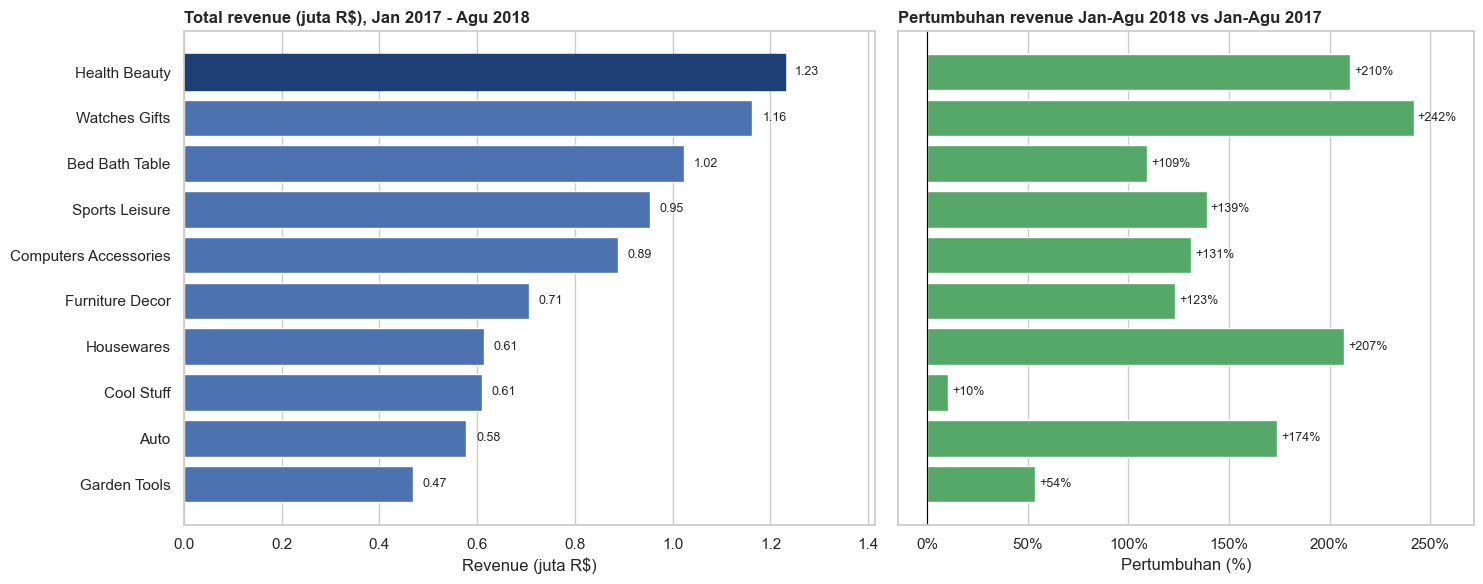

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.2, 1]})
plot_df = top10_growth.sort_values("revenue")
labels = plot_df.index.str.replace("_", " ").str.title()

# kiri: revenue (juta R$)
bars = axes[0].barh(labels, plot_df["revenue"] / 1e6, color="#4C72B0")
bars[-1].set_color("#1F3F77")
for b, v in zip(bars, plot_df["revenue"] / 1e6):
    axes[0].text(v + 0.02, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center", fontsize=9)
axes[0].set_title("Total revenue (juta R$), Jan 2017 - Agu 2018", loc="left", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Revenue (juta R$)")
axes[0].set_xlim(0, plot_df["revenue"].max() / 1e6 * 1.15)

# kanan: pertumbuhan YoY
colors = ["#C44E52" if g < 0 else "#55A868" for g in plot_df["growth_%"]]
axes[1].barh(labels, plot_df["growth_%"], color=colors)
for i, v in enumerate(plot_df["growth_%"]):
    axes[1].text(v + (2 if v >= 0 else -2), i, f"{v:+.0f}%", va="center", ha="left" if v >= 0 else "right", fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_yticklabels([])
axes[1].set_title("Pertumbuhan revenue Jan-Agu 2018 vs Jan-Agu 2017", loc="left", fontsize=12, fontweight="bold")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlim(plot_df["growth_%"].min() - 25, plot_df["growth_%"].max() + 30)
axes[1].set_xlabel("Pertumbuhan (%)")

for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Seberapa besar keterlambatan pengiriman menurunkan review score, dan di state mana keterlambatan paling tinggi?

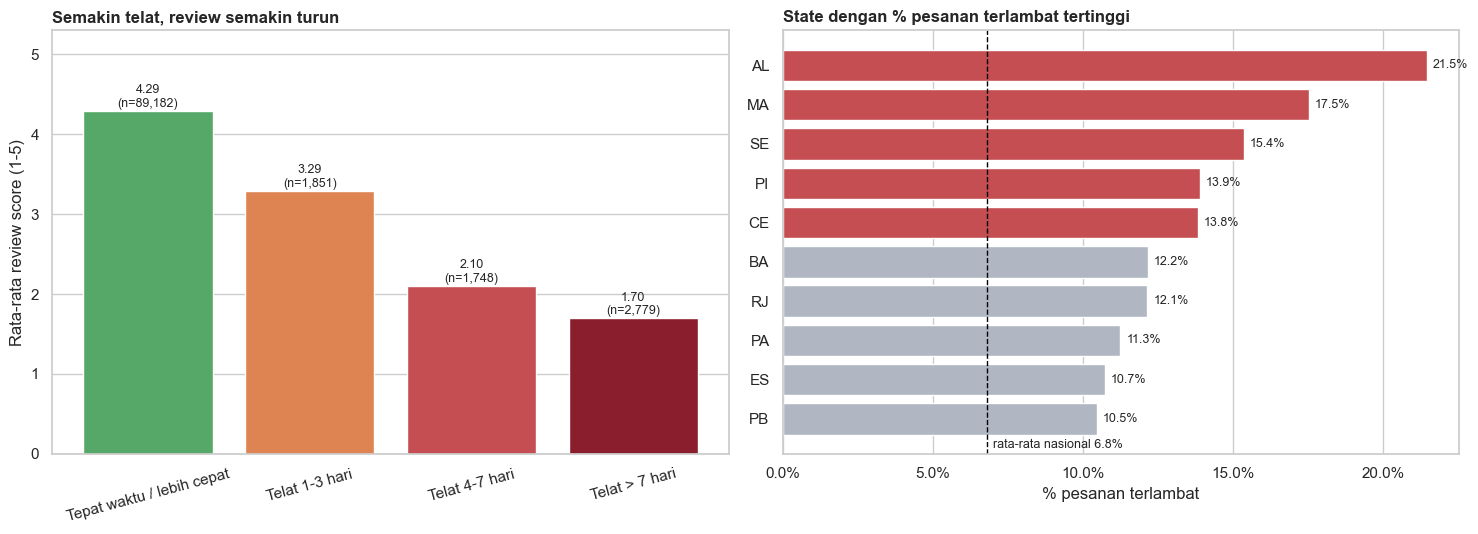

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# kiri: rata-rata review per kelompok keterlambatan
rv = review_by_delay.reset_index()
palette = ["#55A868", "#DD8452", "#C44E52", "#8B1E2D"]
bars = axes[0].bar(rv["delay_bucket"], rv["avg_review"], color=palette)
for b, (_, r) in zip(bars, rv.iterrows()):
    axes[0].text(b.get_x() + b.get_width() / 2, r["avg_review"] + 0.05, f"{r['avg_review']:.2f}\n(n={int(r['orders']):,})",
                 ha="center", fontsize=9)
axes[0].set_ylim(0, 5.3)
axes[0].set_ylabel("Rata-rata review score (1-5)")
axes[0].set_title("Semakin telat, review semakin turun", loc="left", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", labelrotation=15)
axes[0].grid(axis="x", visible=False)

# kanan: top 10 state dengan % terlambat tertinggi (top 5 disorot)
st = state_summary.head(10).sort_values("late_pct")
nat = order_level["is_late"].mean() * 100
cols = ["#C44E52" if s in top5_late.index else "#B0B7C3" for s in st.index]
axes[1].barh(st.index, st["late_pct"], color=cols)
for i, v in enumerate(st["late_pct"]):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
axes[1].axvline(nat, color="black", linestyle="--", linewidth=1)
axes[1].text(nat + 0.2, -0.75, f"rata-rata nasional {nat:.1f}%", fontsize=9)
axes[1].set_title("State dengan % pesanan terlambat tertinggi", loc="left", fontsize=12, fontweight="bold")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel("% pesanan terlambat")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

**Insight:**
- **Pertanyaan 1:** Revenue terkonsentrasi pada beberapa kategori. `health_beauty` dan `watches_gifts` bukan hanya terbesar, tetapi juga tumbuh paling cepat (di atas 200%), sehingga keduanya adalah mesin pertumbuhan utama. Sebaliknya `cool_stuff` yang berada di peringkat 8 hampir stagnan (+10%) dan `garden_tools` melambat (+54%), jauh di bawah pertumbuhan total (141%).
- **Pertanyaan 2:** Keterlambatan pengiriman sangat menurunkan kepuasan pelanggan. Pesanan tepat waktu rata-rata mendapat **4,29**, sedangkan pesanan terlambat hanya **2,27** (selisih 2,02 poin). Semakin lama telat semakin parah: telat 1-3 hari turun ke 3,29, 4-7 hari ke 2,10, dan lebih dari 7 hari ke 1,70 dengan 79% pelanggan memberi skor 1-2 (vs 9% pada pesanan tepat waktu).
- Hanya **6,8%** pesanan terlambat secara nasional, tetapi persentasenya jauh lebih tinggi di wilayah Timur Laut: **AL 21,5%, MA 17,5%, SE 15,4%, PI 13,9%, CE 13,8%**, atau 2-3x rata-rata nasional. State-state ini juga memiliki rata-rata lama kirim 19-24 hari.
- Korelasi `delay_days` dengan review sebesar -0,27 menunjukkan hubungan negatif yang jelas, namun bukan satu-satunya faktor penentu kepuasan (korelasi bukan bukti sebab-akibat penuh).

## Analisis Lanjutan: RFM Analysis (dengan Binning Manual)

**Tujuan:** mengelompokkan pelanggan berdasarkan perilaku belanjanya tanpa algoritma machine learning, supaya tim marketing tahu segmen mana yang perlu dipertahankan, diaktifkan kembali, atau di-upsell.

- **Recency (R):** berapa hari sejak pembelian terakhir (semakin kecil semakin baik)
- **Frequency (F):** jumlah pesanan unik pelanggan
- **Monetary (M):** total belanja (harga produk + ongkir)

Skor R dan M dibuat dengan *binning* kuartil (1-4), sedangkan F dibuat dengan batas manual karena sebagian besar pelanggan hanya membeli satu kali.

In [24]:
snapshot_date = main_df["order_purchase_timestamp"].max().normalize() + pd.Timedelta(days=1)

rfm_df = (main_df.groupby("customer_unique_id")
          .agg(last_purchase=("order_purchase_timestamp", "max"),
               frequency=("order_id", "nunique"),
               monetary=("price", "sum"), freight=("freight_value", "sum")))
rfm_df["monetary"] = rfm_df["monetary"] + rfm_df["freight"]
rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase"]).dt.days
rfm_df = rfm_df[["recency", "frequency", "monetary"]]

# binning manual
rfm_df["R_score"] = pd.qcut(rfm_df["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)       # recency kecil = skor tinggi
rfm_df["F_score"] = pd.cut(rfm_df["frequency"], bins=[0, 1, 2, np.inf], labels=[1, 2, 3]).astype(int)
rfm_df["M_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

def segment(r):
    if r["F_score"] >= 2:
        return "Repeat Customer"
    if r["R_score"] >= 3:
        return "Baru - Belanja Besar" if r["M_score"] >= 3 else "Baru - Belanja Kecil"
    return "Berisiko Hilang - Belanja Besar" if r["M_score"] >= 3 else "Tidak Aktif - Belanja Kecil"

rfm_df["segment"] = rfm_df.apply(segment, axis=1)
seg_order = ["Repeat Customer", "Baru - Belanja Besar", "Baru - Belanja Kecil",
             "Berisiko Hilang - Belanja Besar", "Tidak Aktif - Belanja Kecil"]
seg_summary = (rfm_df.groupby("segment")
               .agg(customers=("recency", "count"), avg_recency=("recency", "mean"),
                    avg_frequency=("frequency", "mean"), avg_monetary=("monetary", "mean"), total_monetary=("monetary", "sum"))
               .reindex(seg_order))
seg_summary["customers_%"] = seg_summary["customers"] / seg_summary["customers"].sum() * 100
seg_summary["revenue_%"] = seg_summary["total_monetary"] / seg_summary["total_monetary"].sum() * 100
print(f"Pelanggan dengan >1 pesanan: {(rfm_df['frequency'] > 1).mean():.1%}")
seg_summary.round(1)

Pelanggan dengan >1 pesanan: 3.0%


,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,customers_%,revenue_%
segment,,,,,,,
Repeat Customer,2789,219.1,2.1,308.5,860533.2,3.0,5.6
Baru - Belanja Besar,22423,110.9,1.0,261.2,5856186.4,24.1,38.1
Baru - Belanja Kecil,22589,111.0,1.0,63.0,1423149.3,24.3,9.3
Berisiko Hilang - Belanja Besar,21670,361.6,1.0,264.2,5724712.1,23.3,37.2
Tidak Aktif - Belanja Kecil,23625,362.0,1.0,63.8,1507160.2,25.4,9.8


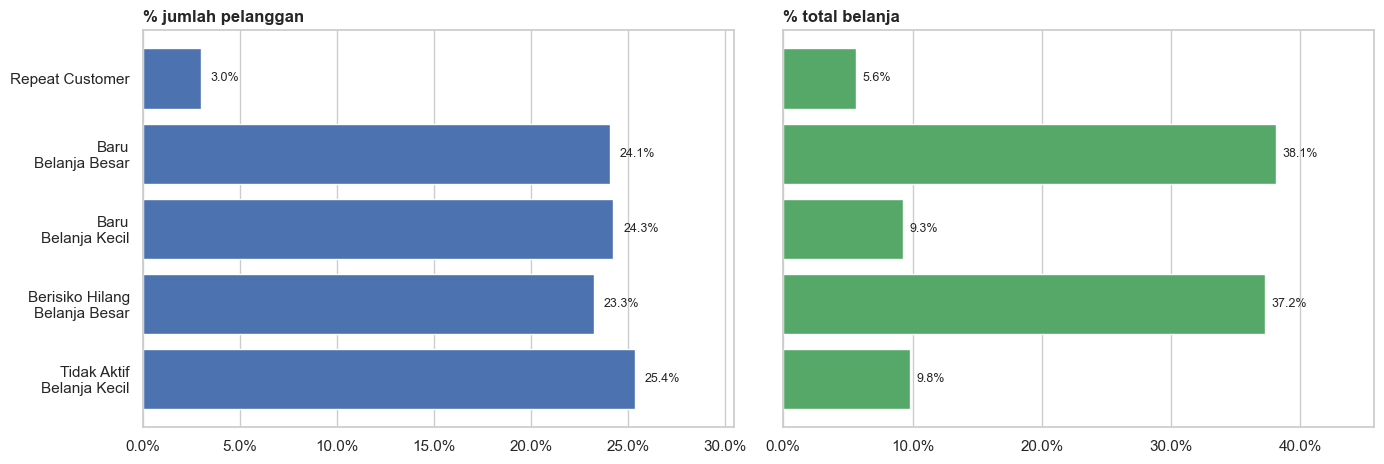

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
y = seg_summary.index.str.replace(" - ", "\n").tolist()
axes[0].barh(y, seg_summary["customers_%"], color="#4C72B0")
axes[1].barh(y, seg_summary["revenue_%"], color="#55A868")
for ax, col, ttl in [(axes[0], "customers_%", "% jumlah pelanggan"), (axes[1], "revenue_%", "% total belanja")]:
    for i, v in enumerate(seg_summary[col]):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_title(ttl, loc="left", fontsize=12, fontweight="bold")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, max(seg_summary[col]) * 1.2)
    ax.grid(axis="y", visible=False)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:**
- Hanya **3,0%** pelanggan yang pernah membeli lebih dari satu kali, sehingga basis pelanggan didominasi pembeli sekali (one-time buyer) dan retensi menjadi peluang terbesar.
- Segmen **Baru - Belanja Besar** (24% pelanggan) menghasilkan **38% total belanja**, dan segmen **Berisiko Hilang - Belanja Besar** (23% pelanggan, terakhir belanja rata-rata 362 hari lalu) menyumbang **37%**. Artinya sekitar 75% nilai belanja berasal dari pelanggan bernilai besar yang baru membeli satu kali.
- Pelanggan *Repeat* hanya 3% tetapi rata-rata belanjanya (R$ 308) tertinggi, menunjukkan nilai pelanggan yang kembali membeli.
- Segmen belanja kecil (49,6% pelanggan) hanya menghasilkan sekitar 19% total belanja sehingga bukan prioritas kampanye berbiaya tinggi.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** 10 kategori teratas menyumbang 62,5% revenue selama Jan 2017 - Agu 2018, dipimpin `health_beauty` (R$ 1,23 juta), `watches_gifts` (R$ 1,16 juta), dan `bed_bath_table` (R$ 1,02 juta). Pada Jan-Agu 2018 vs 2017 seluruh kategori teratas tumbuh, dengan `watches_gifts` (+242%) dan `health_beauty` (+210%) tumbuh tercepat, sedangkan `cool_stuff` (+10%) dan `garden_tools` (+54%) tertinggal jauh dari pertumbuhan total 141%.
- **Conclusion pertanyaan 2:** Keterlambatan pengiriman menurunkan rata-rata review dari 4,29 (tepat waktu) menjadi 2,27 (terlambat), dan turun hingga 1,70 bila telat lebih dari 7 hari. Meski hanya 6,8% pesanan yang terlambat secara nasional, 5 state teratas yaitu AL (21,5%), MA (17,5%), SE (15,4%), PI (13,9%), dan CE (13,8%) memiliki tingkat keterlambatan 2-3x lipat.
- **Analisis lanjutan (RFM):** hanya 3% pelanggan yang repeat order, dan sekitar 75% nilai belanja berasal dari pelanggan bernilai besar yang baru membeli sekali (aktif maupun berisiko hilang).

**Rekomendasi Action Item:**
- **Merchandising:** prioritaskan anggaran promosi dan rekrutmen seller untuk `health_beauty` dan `watches_gifts` karena keduanya terbesar sekaligus tumbuh tercepat; lakukan evaluasi harga/seller/promosi pada `cool_stuff` dan `garden_tools` yang pertumbuhannya melambat.
- **Logistik:** tim logistik memprioritaskan perbaikan pengiriman ke AL, MA, SE, PI, dan CE (misalnya menambah mitra kurir/hub regional atau memperlonggar estimasi agar lebih realistis) dengan target menurunkan persentase terlambat dari 13-21% menuju mendekati rata-rata nasional (6,8%).
- **Layanan pelanggan:** kirim notifikasi proaktif dan kompensasi (voucher/pengembalian ongkir) otomatis saat pesanan diprediksi telat lebih dari 3 hari, karena pada titik inilah review turun drastis (di bawah 2,5).
- **Marketing/CRM:** jalankan kampanye reaktivasi (voucher dan rekomendasi produk) khusus untuk segmen *Berisiko Hilang - Belanja Besar* dan program retensi bagi *Baru - Belanja Besar* sebelum menjadi tidak aktif, karena segmen ini membawa sekitar 75% nilai belanja.
- **Catatan pengembangan analisis:** jika data lebih lengkap tersedia, uji pengaruh jarak penjual-pembeli (geospatial) terhadap keterlambatan di Timur Laut Brasil untuk menentukan lokasi hub yang tepat.